# Aula 19


# Treinamento customizado com TensorFlow


### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

Apresentar como realizar treinamento customizado com o TensorFlow

Apresentar um exemplo de treinamento customizado de uma RNA com o TensorFlow.

### Importação das bilbiotecas necessárias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)

2.4.1


## 2. Introdução

Na aula anterior vimos como calcular gradientes com o TensorFlow e resolvemos um problema de ajuste de função.

Nessa aula vamos treinar uma RNA calculando o gradiente da função de custo em relação aos parâmetros da RNA e aplicar esse gradiente para atualizar os parâmetros usando um dos métodos de otimização que já conhecemos.

Para esse exemplo de treinamento customizado vamos desenvolver uma RNA para classificar as imagens de dígitos do conjunto MNIST.

## 3. Carregar e processar dados

A célula abaixo carrega o conjunto de dados de dígitos MNIST da coleção do Keras.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Dimensão dos dados de entrada de treinamento =', x_train.shape)
print('Dimensão dos dados de entrada de teste =', x_test.shape)
print('Dimensão dos dados de saída de treinamento =', y_train.shape)
print('Dimensão dos dados de saída de teste =', y_test.shape)

Dimensão dos dados de entrada de treinamento = (60000, 28, 28)
Dimensão dos dados de entrada de teste = (10000, 28, 28)
Dimensão dos dados de saída de treinamento = (60000,)
Dimensão dos dados de saída de teste = (10000,)


Como as imagens do conjunto de dígitos MNIST são pequenas e em tons de cinza, para simplificar vamos transformar as imagens em vetores e usar uma rede com camadas densas.

Dessa forma é necessário redimensionar as imagens para torná-las vetores.

In [ ]:
# Número total de pixels nas imagens
nx = x_train.shape[1]*x_train.shape[2]

# Redimensionamento das imagens
x_train_flat = np.reshape(x_train, (x_train.shape[0], nx))/255.
x_test_flat = np.reshape(x_test, (x_test.shape[0], nx))/255.

print('Dimensão dos dados de entrada de treinamento =', x_train_flat.shape)
print('Dimensão dos dados de entrada de teste =', x_test_flat.shape)

Dimensão dos dados de entrada de treinamento = (60000, 784)
Dimensão dos dados de entrada de teste = (10000, 784)


#### Gráficos de alguns exemplos

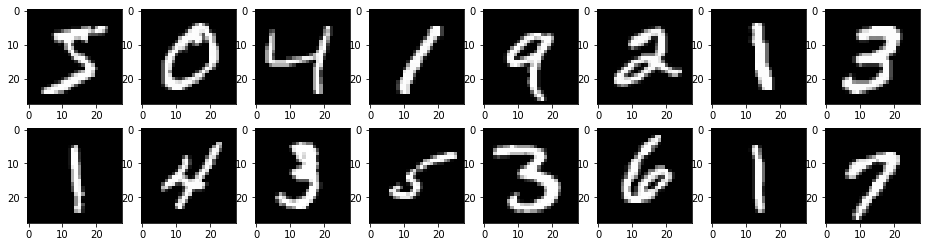

In [ ]:
fig, axs = plt.subplots(2,8, figsize=(16,4))
index = 0
for i in range(2):
    for j in range(8):
        axs[i,j].imshow(x_train[index], cmap='gray')
        index += 1
plt.show()

#### Transformação das saídas em vetores one-hot

In [ ]:
y_train_hot = tf.one_hot(y_train, 10)
y_test_hot = tf.one_hot(y_test, 10)

print('Dimensão dos dados de saída de treinamento =', y_train_hot.shape)
print('Dimensão dos dados de saída de teste =',y_test_hot.shape)

Dimensão dos dados de saída de treinamento = (60000, 10)
Dimensão dos dados de saída de teste = (10000, 10)


## 4. Configuração da RNA

Para resolver essa tarefa de classificação multiclasse vamos utlizar uma RNA com camadas densas com a seguinte configuração:

- Primeira camada: 128 neurônios e função de ativação Relu;
- Segunda camada: 64 neurônios e função de ativação Relu;
- Camada de saída: 1 neurônio e função de ativação softmax.

In [ ]:
# Importa classes
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Configura RNA
rna = Sequential()
rna.add(Dense(128, activation='relu', input_shape=(784,)))
rna.add(Dense(64, activation='relu'))
rna.add(Dense(10, activation='softmax'))

# Resumo da RNA
rna.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 128)               100480    
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_2 (Dense)              (None, 10)                650       
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
_________________________________________________________________


## 5. Compilação da RNA

A compilação da RNA segue a seguinte configuração:
    
- Otimizador: Adam com taxa de aprendizado de 0.001;
- Função de custo: Categorical Crossentropy
- Métrica: Accuracy

Para realizar um treinamento customizado devemos criar objetos com o otimizador, com a função de custo e com a métrica.

Para criar esses objetos deve-se usar as versões na forma de classes de todas essas funções, conforme realizado na célula abaixo.

In [ ]:
# Define objeto otimizador usando tf.keras.optimizer.Addam
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Define objeto função de custo usando tf.keras.losses.BinaryCrossentropy
loss_object = tf.keras.losses.CategoricalCrossentropy()

# Define objeto métrica usando tf.keras.metrics.BinaryAccuracy
metric_object = tf.keras.metrics.CategoricalAccuracy()

## 6. Teste da RNA, da função de custo e da métrica

Vamos avaliar a RNA não treinada, juntamente com a função de custo e a métrica, para verificar se estão corretas e também para termos uma base do resultado esperado do treinamento.

In [ ]:
# Calcula previsões da RNA não treinada
outputs = rna.predict(x_test_flat)

# Calcula função de custo
loss_value = loss_object(y_true=y_test_hot, y_pred=outputs)
print("Custo antes do treinamento =", loss_value.numpy())

# Calcula métrica
accuracy = metric_object(y_true=y_test_hot, y_pred=outputs)
print("Métrica antes do treinamento =", accuracy.numpy())

Custo antes do treinamento = 2.3532958
Métrica antes do treinamento = 0.1012


In [ ]:
# Identifica as classes previstas
y_pred = tf.math.argmax(outputs, axis=1)

print('Classes previstas do primeiros 5 exemplos:', y_pred[:5].numpy())

Classes previstas do primeiros 5 exemplos: [0 1 0 0 0]


### 6.1 Matriz de confusão

Para permitir uma visualização melhor do resutado do treinamento vamos usar a matriz de confusão dos resutados previstos pela RNA.

Na célula abaixo é criada uma função para calcular e mostrar a matriz de confusão.

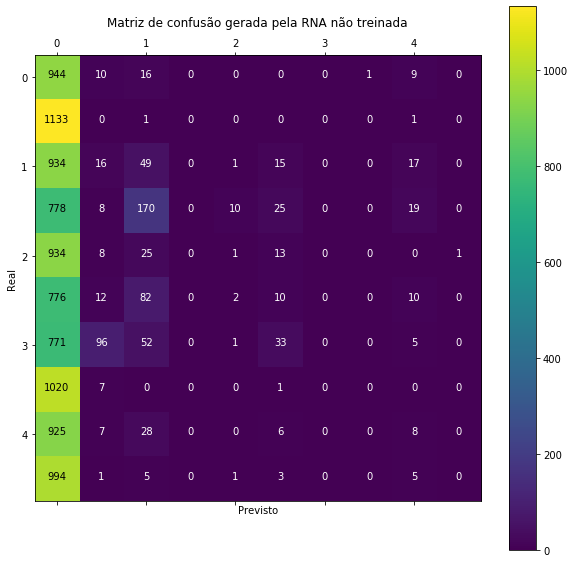

In [ ]:
# Importa funções para calcula matriz e confusão
from sklearn.metrics import confusion_matrix
import itertools

# Define função para construir matriz de confusão
def plot_confusion_matrix(y_true, y_pred, title='', labels=[0,1,2,3,4,5,6,7,8,9]):
    cm = confusion_matrix(y_true, y_pred)
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    cax = ax.matshow(cm)
    plt.title(title)
    fig.colorbar(cax)
    ax.set_xticklabels([''] + labels)
    ax.set_yticklabels([''] + labels)
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
          plt.text(j, i, format(cm[i, j], fmt),
                  horizontalalignment="center",
                  color="black" if cm[i, j] > thresh else "white")
    plt.show()

plot_confusion_matrix(y_test, y_pred, title='Matriz de confusão gerada pela RNA não treinada')

- Observa-se que os resultados antes do treinamento da RNA são muotruins.

## 7. Treinamento da RNA

Para treinar essa RNA vamos criar um loop customizado usando a função `tf.GradientTape()`.


### 7.1 Cálculo do gradiente e atualização dos parâmetros

Para calcular o gradiente da função de custo em relação aos parâmetros da RNA e depois atualizar esses parâmetros usando o otimizador configurado anteriormente, vamos criar uma função.

Essa função processa e atualiza os parâmetros da rede para um lote de dados.

**Para acessar os parâmetros de um modelo do TensorFlow basta usar `model.trainable_weights`.**

In [ ]:
# Função que calcula gradientes e atualiza parâmetros da RNA
def train_step(optimizer, loss_object, model, x, y):
    '''
    Função para calcular o gradiente e atualizar os parâmetros da RNA

    Argumentos:
        optimizer: otimizador configurado para atualizar os parâmetros
        loss_object: função de custo configurada anteriormente
        model: RNA que está sendo treinada
        x: tensor com os dados de entrada de treinamento
        y: saídas desejadas dos dados de treinamento

    Retorna:
        y_pred = saídas previstas pela RNA
        loss_value = valor da função de custo
    '''

    with tf.GradientTape() as tape:
        y_pred = model(x)
        loss_value = loss_object(y_true=y, y_pred=y_pred)

    gradients = tape.gradient(loss_value, model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    return y_pred, loss_value

### 7.2 Cálculo do custo e da métrica para os dados de validação

No final de cada época de treinamento, temos que validar a RNA no conjunto de dados de validação. Para isso vamos criar uma função que calcula a função de custo e a métrica para os dados de validação.

In [ ]:
# Função para calcular custo e métrica dos dados de validação
def perform_validation(model, x_val, y_val):
    # Calcula saídas previstas dos dados de validação
    val_prev = model(x_val)

    #Calcula custo dos dados de validação
    val_loss = loss_object(y_true=y_val, y_pred=val_prev)

    # Calcula métrica para dados de validação
    val_accuracy = metric_object(y_val, val_prev)

    return val_loss, val_accuracy

### 7.3 Lote de dados

Para dividirmos os dados em lotes de treinamento temos duas opções:

1. Criar um gerador de dados para gerar os lotes;
2. Colocar os dados em um `dataset` do TensorFlow.

Nesse exemplo, vamos utilizar um gerador de dados para gerar os lotes.

Na célula abaixo é criado o gerador de dados.

Observe que esse gerador está preparado para criar lotes completos de dados, assim, se o número de exemplos não for um múltiplo inteiro do número de exemplos de cada lote, alguns exemplos não serão usados no treinamento.

In [ ]:
# Função para gerar lotes de dados
def generate_batches(x_train, y_train, batch_size):

    # Calcula número de lotes completos
    num_batches = len(y_train) // batch_size

    # Usa somente lotes completos
    x_train = x_train[:num_batches * batch_size]
    y_train = y_train[:num_batches * batch_size]

    for ind in range(0, len(y_train), batch_size):
        input_vals, target = [], []

        inputs = x_train[ind:ind + batch_size]
        outputs = y_train[ind:ind + batch_size]

        input_vals.extend(inputs)
        target.extend(outputs)

        yield np.stack(input_vals), np.stack(target)

Teste do gerador de dados.

In [ ]:
# Instancia gerador
batches = generate_batches(x_train_flat, y_train_hot, 20)

# Utiliza o gerador um vez
x1, y1 = next(batches)
x2, y2 = next(batches)
print('Dimensão do lote de dados de entrada e de saída:', x1.shape, y1.shape)
print('Dimensão do lote de dados de entrada e de saída:', x2.shape, y2.shape)
print(y1)
print(y2)

Dimensão do lote de dados de entrada e de saída: (20, 784) (20, 10)
Dimensão do lote de dados de entrada e de saída: (20, 784) (20, 10)
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 

#### Loop de treinamento customizado

Usando a função `apply_gradient()` vamos criar um loop de treinamemto customizado. Vamos utilizar 50 épocas de treinamento.

In [ ]:
# Loop de treinamento customizado

# Define número de épocas
num_epocas = 20

# Define tamanho do lote
batch_size = 1000

# Número de lotes por época
num_lotes = len(y_train) // batch_size

# Incializa vetores de custo e métricas
train_loss = np.zeros(num_epocas)
train_accuracy = np.zeros(num_epocas)
val_loss = np. zeros(num_epocas)
val_accuracy = np.zeros(num_epocas)

# Loop de treinamento
for i in range(num_epocas):

    # Instancia gerador de lotes no início de cada época
    batches = generate_batches(x_train_flat, y_train_hot, batch_size)

    # Inicializa custo e métrica no início de cada época
    accuracy_batch = []
    loss_batch = []

    # Percorre os lotes de dados
    for j in range(num_lotes):

        # Gera um lote de dados
        x, y = next(batches)

        # Calcula gradientes e atualiza parâmetros da RNA
        y_pred, loss_value = train_step(optimizer, loss_object, rna, x, y)

        # Calcula métrica para dados de treinamento
        metric = metric_object(y, y_pred)

        # Acumula custo e métrica de cada lote para ter valor médio no final dde cada época
        loss_batch.append(loss_value)
        accuracy_batch.append(metric)

    # Calcula custo e métrica médios dos dados de treinamento
    loss = np.mean(np.array(loss_batch))
    accuracy = np.mean(np.array(accuracy_batch))

    # Guarda valores do custo e métrica dos dados de treinamento para fazer gráfico posteriomente
    train_loss[i] = loss
    train_accuracy[i] = accuracy

    # Calcula função de custo e métrica para todos os dados de validação
    val_loss[i], val_accuracy[i] = perform_validation(rna, x_test_flat, y_test_hot)

    # Imprime resultado da função de custo e métrica da época
    print('Época:', i, '-', 'custo =', loss, '-', 'exatidão =', accuracy, '-', 'custo_val =', val_loss[i], '-', 'val_exatidão =', val_accuracy[i])

# Imprime resultado final
print('\nCusto final =', loss)
print('Exatidão final=', accuracy)
print('\nCusto final de validação =', val_loss[num_epocas-1])
print('Exatidão final de validação =', val_accuracy[num_epocas-1])

Época: 0 - custo = 0.86019653 - exatidão = 0.45705125 - custo_val = 0.32195889949798584 - val_exatidão = 0.6964750289916992
Época: 1 - custo = 0.2823504 - exatidão = 0.7523765 - custo_val = 0.23300640285015106 - val_exatidão = 0.8010466694831848
Época: 2 - custo = 0.21850482 - exatidão = 0.82265186 - custo_val = 0.19176188111305237 - val_exatidão = 0.8446682095527649
Época: 3 - custo = 0.18204413 - exatidão = 0.8565904 - custo_val = 0.1664145141839981 - val_exatidão = 0.8696413636207581
Época: 4 - custo = 0.15631066 - exatidão = 0.8774292 - custo_val = 0.14870429039001465 - val_exatidão = 0.8863027691841125
Época: 5 - custo = 0.13606372 - exatidão = 0.8919304 - custo_val = 0.13535405695438385 - val_exatidão = 0.898465096950531
Época: 6 - custo = 0.11988977 - exatidão = 0.90278244 - custo_val = 0.12512075901031494 - val_exatidão = 0.9078480005264282
Época: 7 - custo = 0.10663942 - exatidão = 0.91130805 - custo_val = 0.11662512272596359 - val_exatidão = 0.9153508543968201
Época: 8 - cust

- Observa-se que usar a estrutura `dataset` do TensorFlow é mais rápido do que usar um gerador de dados customizado.

Gráfico do processo de treinamento.

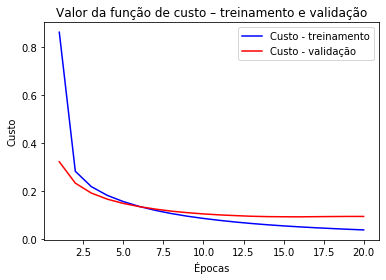

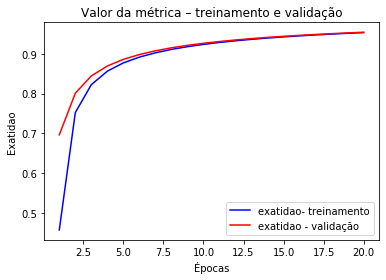

In [ ]:
# Cria vetor de épocas
epocas = range(1, num_epocas + 1)

# Gráfico dos valores de custo
plt.plot(epocas, train_loss, 'b', label='Custo - treinamento')
plt.plot(epocas, val_loss, 'r', label='Custo - validação')
plt.title('Valor da função de custo – treinamento e validação')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.legend()
plt.show()

# Gráfico dos valores da métrica
plt.plot(epocas, train_accuracy, 'b', label='exatidao- treinamento')
plt.plot(epocas, val_accuracy, 'r', label='exatidao - validação')
plt.title('Valor da métrica – treinamento e validação')
plt.xlabel('Épocas')
plt.ylabel('Exatidao')
plt.legend()
plt.show()

### 7.4 Avaliação e teste da RNA

Calculo da matriz de confusão para a RNA treinada.

Classes previstas do primeiros 5 exemplos: [7 2 1 0 4]


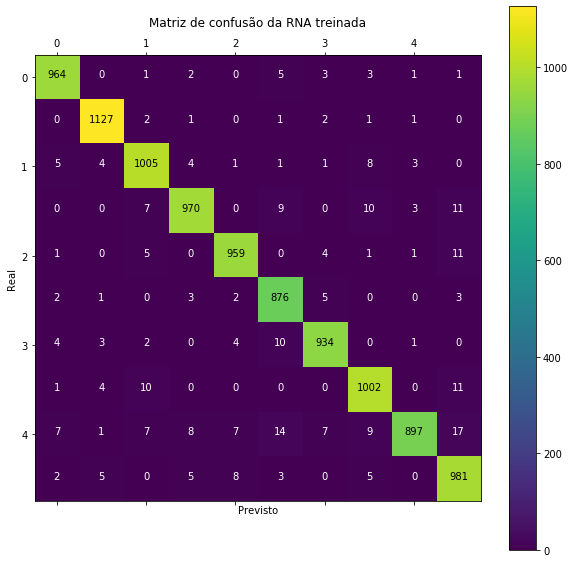

In [ ]:
# Calcula saída prevista para os dados de teste
outputs = rna.predict(x_test_flat)

# Identifica as classes previstas
y_pred = tf.math.argmax(outputs, axis=1)

print('Classes previstas do primeiros 5 exemplos:', y_pred[:5].numpy())

# calcula e mostra matriz de confusão
plot_confusion_matrix(y_test, y_pred, title='Matriz de confusão da RNA treinada')

#### Comparação das saídas previstas e reais

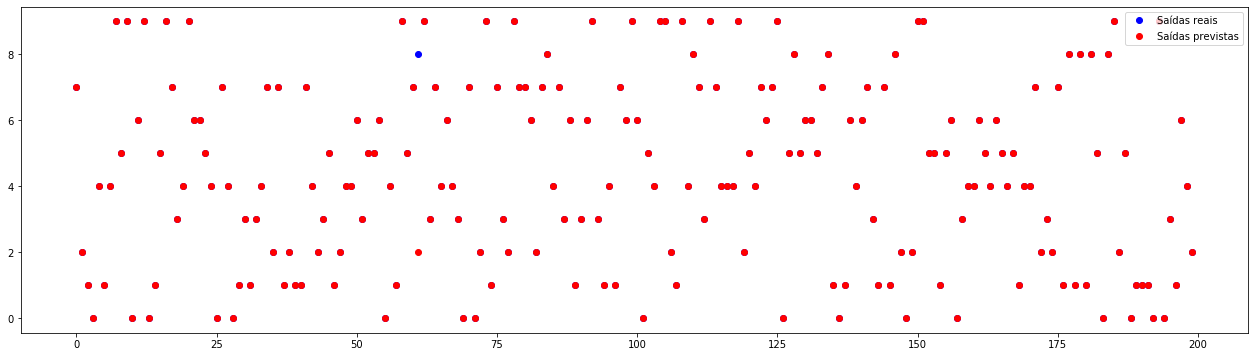

In [ ]:
# verificação dos 200 primeiros exemplos de teste
plt.figure(figsize=(22,6))
plt.plot(y_test[:200], 'bo', label='Saídas reais')
plt.plot(y_pred[:200], 'ro', label='Saídas previstas')
plt.legend()
plt.show()

In [ ]:
val_loss_mean, val_accuracy_mean = perform_validation(rna, x_test_flat, y_test_hot)
print(val_loss_mean.numpy(), val_accuracy_mean.numpy())

0.09464393 0.9549153
